In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


In [2]:
data = pd.read_csv("iris.csv")


In [3]:
print(data.head())
print(data.tail())
print(data.info())
print(data.describe())
print(data.ndim)
print(data.size)
print(data.dtypes)
print(data.memory_usage())
print(data.count())
print(data.isnull())
print(data.isnull().sum())
print(data.isnull().sum().sum())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
     sepal_length  sepal_width  petal_length  petal_width    species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 

3


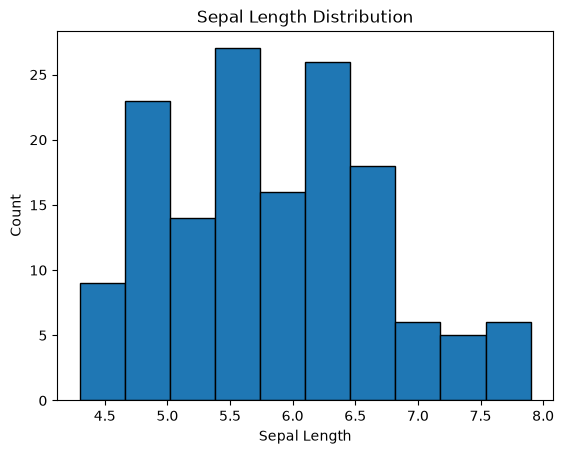

Accuracy : 1.0
Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Predicted Species : Virginica


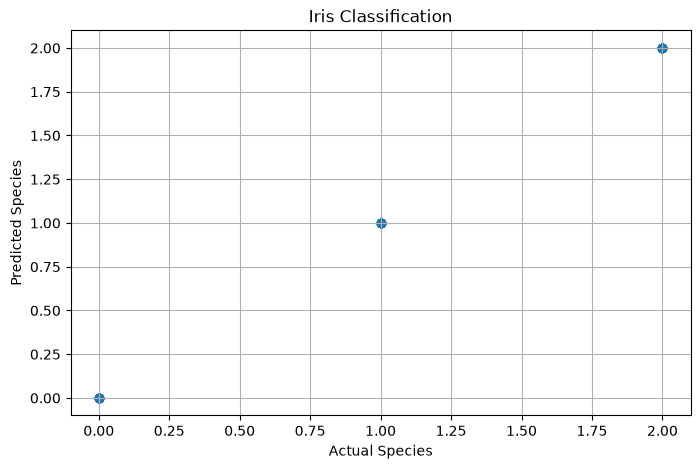

In [4]:
data["sepal_length"] = data["sepal_length"].fillna(data["sepal_length"].median())
data["sepal_width"] = data["sepal_width"].fillna(data["sepal_width"].median())
data["petal_length"] = data["petal_length"].fillna(data["petal_length"].median())
data["petal_width"] = data["petal_width"].fillna(data["petal_width"].median())

print(data.duplicated().sum())

plt.hist(data["sepal_length"], edgecolor="black")
plt.title("Sepal Length Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Count")
plt.show()

data["species"] = data["species"].map({
    "setosa":0,
    "versicolor":1,
    "virginica":2
})

x = data[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]]

y = data["species"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=200)

model.fit(x_train, y_train)

prediction = model.predict(x_test)

print("Accuracy :", accuracy_score(y_test, prediction))

print("Confusion Matrix")
print(confusion_matrix(y_test, prediction))

sl = float(input("Enter Sepal Length: "))
sw = float(input("Enter Sepal Width: "))
pl = float(input("Enter Petal Length: "))
pw = float(input("Enter Petal Width: "))

result = model.predict([[sl, sw, pl, pw]])

if result[0] == 0:
    print("Predicted Species : Setosa")
elif result[0] == 1:
    print("Predicted Species : Versicolor")
else:
    print("Predicted Species : Virginica")


plt.figure(figsize=(8,5))
plt.scatter(y_test, prediction)
plt.xlabel("Actual Species")
plt.ylabel("Predicted Species")
plt.title("Iris Classification")
plt.grid(True)
plt.show()